In [2]:
import matplotlib.pyplot as plt

import gudhi as gd 
import numpy as np 
import tensorflow as tf 
import pandas as pd

from utils import *

from matplotlib import gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

Calculate persistent entropy transform of a signal/function

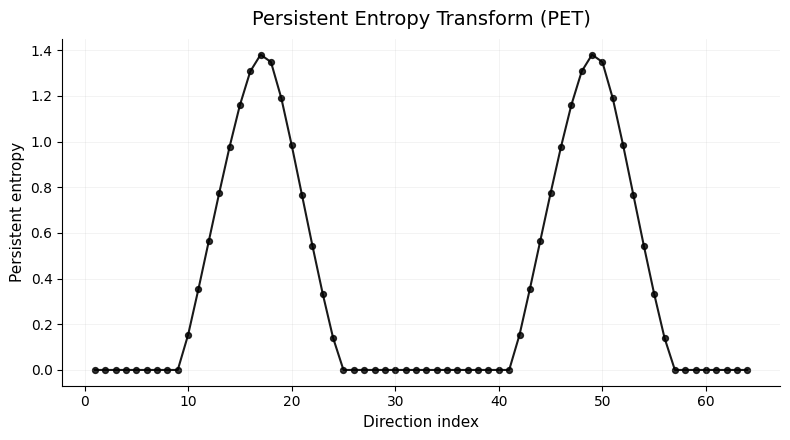

In [3]:
domain =[-10,10]
function=np.sin
n_points = 250
x_train, y_train = generate_training_data(function, (domain[0], domain[1]), n_points)
x_train = tf.constant(x_train,dtype=tf.float32)
y_train = tf.constant(y_train,dtype=tf.float32)

stbase = gd.SimplexTree()
for i in range(n_points-1):
    stbase.insert([i,i+1], -1e10)
layer = LowerStarLayer(simplextree=stbase)

dgmsRef = layer.call(y_train)
dgmRef = dgmsRef[0][0]
PERef=persistent_entropy(dgmRef)


# =========================================================
# Compute PET
# =========================================================

PET_values, angles = persistent_entropy_transform(
    x_train,
    y_train,
    layer,
    num_directions=64
)

PET_values = PET_values.numpy()

# =========================================================
# Create figure
# =========================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

direction_index = np.arange(1, len(PET_values) + 1)

# Main PET curve
ax.plot(
    direction_index,
    PET_values,
    linewidth=1.5,
    color='black',
    alpha=0.9
)

# Scatter points
ax.scatter(
    direction_index,
    PET_values,
    s=18,
    color='black',
    alpha=0.8
)

# =========================================================
# Labels
# =========================================================

ax.set_xlabel(
    "Direction index",
    fontsize=11
)

ax.set_ylabel(
    "Persistent entropy",
    fontsize=11
)

ax.set_title(
    "Persistent Entropy Transform (PET)",
    fontsize=14,
    pad=10
)

# =========================================================
# Paper style
# =========================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    alpha=0.2,
    linewidth=0.5
)

plt.tight_layout()
plt.savefig("figures/Pet.jpg")
plt.show()

Display the signal from each direction

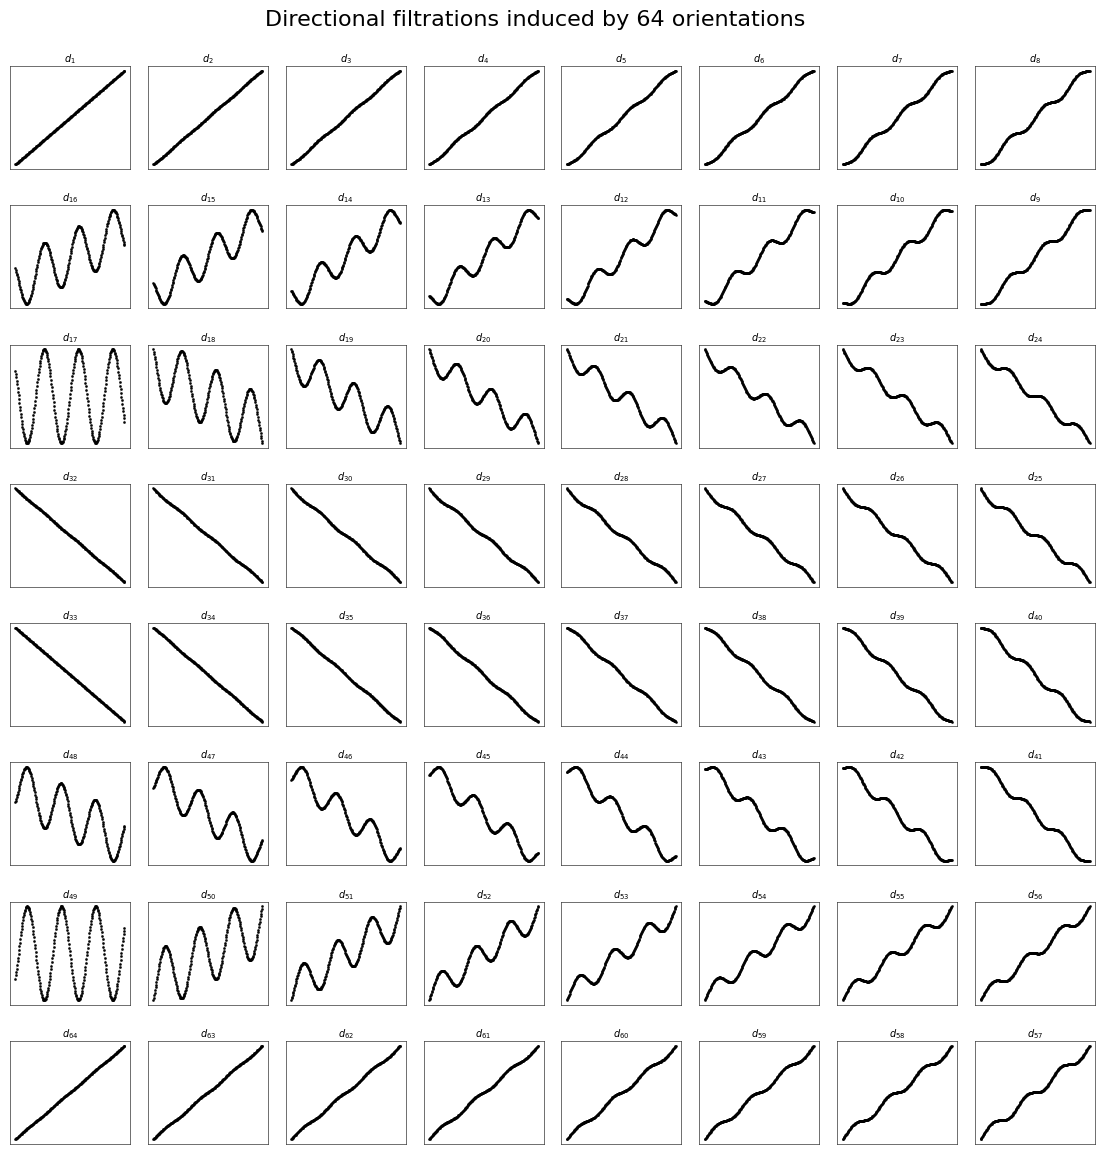

In [4]:
# display the signal from each direction

# =========================================================
# Generate directions
# =========================================================

num_directions = 64
directions, angles = generate_directions_2D(num_directions)

# =========================================================
# Reorder directions in snake-like layout
# Left -> Right
# Right -> Left
# =========================================================

grid_size = 8

ordered_indices = []

for row in range(grid_size):

    start = row * grid_size
    end = (row + 1) * grid_size

    row_indices = list(range(start, end))

    # Reverse every second row
    if row % 2 == 1:
        row_indices = row_indices[::-1]

    ordered_indices.extend(row_indices)

# =========================================================
# Create figure
# =========================================================

fig = plt.figure(figsize=(14, 14))

gs = gridspec.GridSpec(
    grid_size,
    grid_size,
    wspace=0.15,
    hspace=0.35
)

# =========================================================
# Plot directional filtrations
# =========================================================

for plot_position, k in enumerate(ordered_indices):

    direction = directions[k]

    filtration_values = directional_height_function(
        x_train,
        y_train,
        direction
    )

    ax = plt.subplot(gs[plot_position])

    x_axis = np.arange(len(filtration_values))

    ax.plot(
        x_axis,
        filtration_values,
        linewidth=0.1,
        alpha=0.85,
        color='black'
    )

    ax.scatter(
        x_axis,
        filtration_values,
        s=1,
        alpha=0.85,
        color='black'
    )

    # Minimal paper style
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        rf"$d_{{{k+1}}}$",
        fontsize=7,
        pad=2
    )

    # Thin borders
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

# =========================================================
# Global title
# =========================================================

plt.suptitle(
    "Directional filtrations induced by 64 orientations",
    fontsize=16,
    y=0.92
)

plt.savefig("figures/DirectionalFiltrations.jpg")
plt.show()


#empiezas viendolo de izquierda a derecha en el eje horizontal, asi hasta la 32 direccion, y luego de derecha a izquierda en el eje horizontal, asi hasta la 64 direccion.

empiezas viendolo de izquierda a derecha en direccion 1, ahi hasta la direccion 17 (1,57 radianes), que es de abajo a arriba, de ahi hasta la direccion 33 (3,14 radianes) que es de derecha a izquierda, y ahora por arriba igual hasta llegar a direccion 64 que es volver  casi a punto de partida


Propiedades:



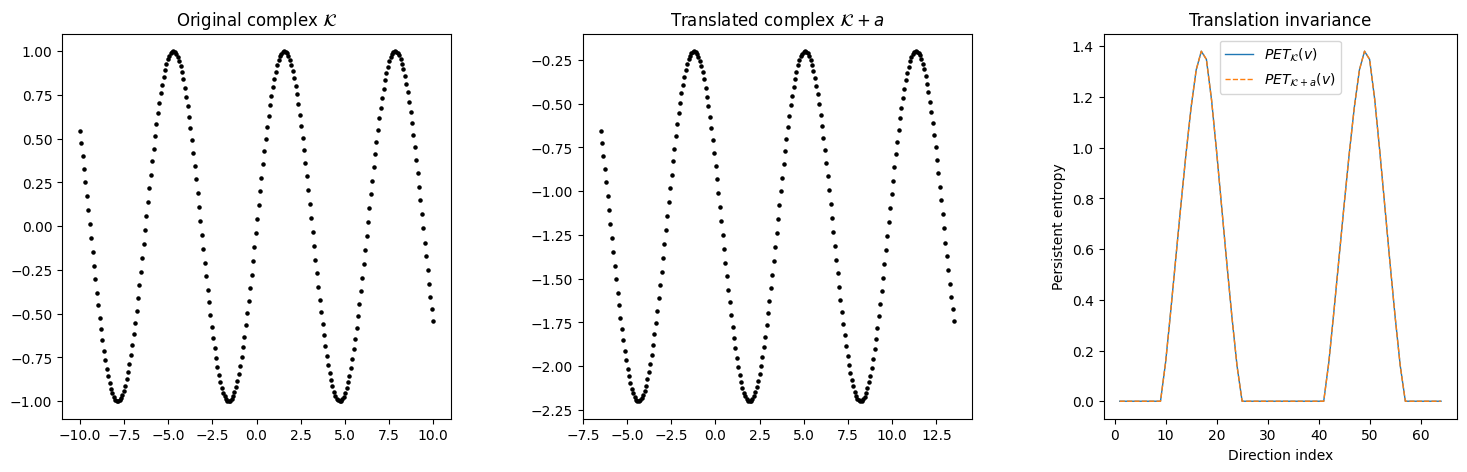

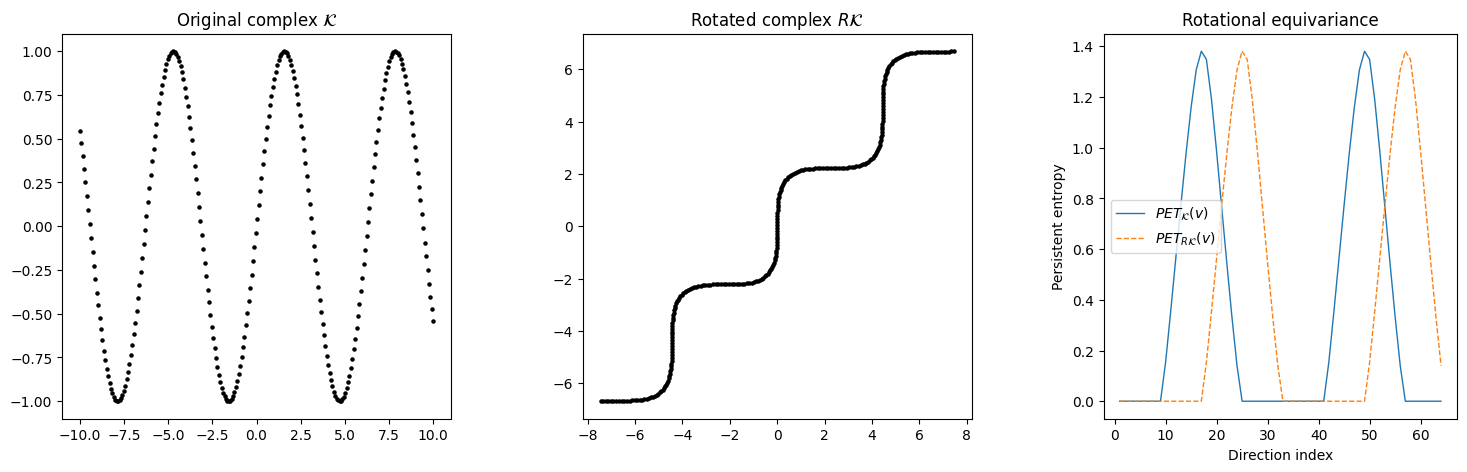

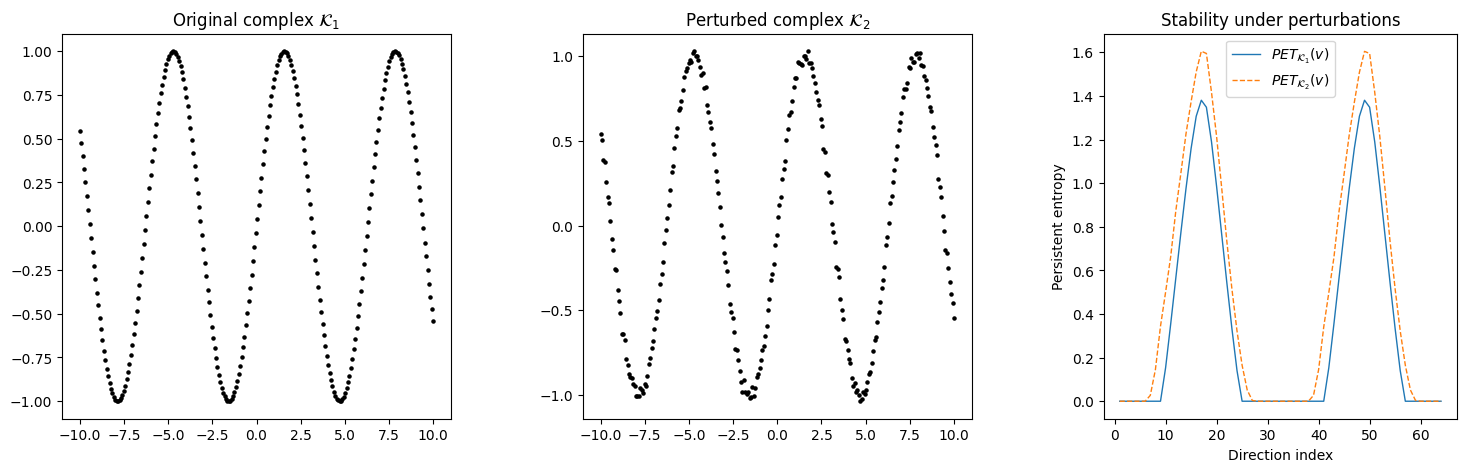

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch

# =========================================================
# DATA
# =========================================================

domain = [-10, 10]
function = np.sin
n_points = 250

x_train, y_train = generate_training_data(
    function,
    (domain[0], domain[1]),
    n_points
)

x_train = tf.constant(x_train, dtype=tf.float32)
y_train = tf.constant(y_train, dtype=tf.float32)

# =========================================================
# SIMPLEX TREE
# =========================================================

stbase = gd.SimplexTree()

for i in range(n_points - 1):
    stbase.insert([i, i + 1], -1e10)

layer = LowerStarLayer(simplextree=stbase)

# =========================================================
# PET ORIGINAL
# =========================================================

PET_original, angles = persistent_entropy_transform(
    x_train,
    y_train,
    layer,
    num_directions=64
)

PET_original = PET_original.numpy()

# =========================================================
# TRANSLATION
# =========================================================

translation = np.array([3.5, -1.2])

x_translation = x_train.numpy() + translation[0]
y_translation = y_train.numpy() + translation[1]

x_translation_tf = tf.constant(x_translation, dtype=tf.float32)
y_translation_tf = tf.constant(y_translation, dtype=tf.float32)

PET_translation, _ = persistent_entropy_transform(
    x_translation_tf,
    y_translation_tf,
    layer,
    num_directions=64
)

PET_translation = PET_translation.numpy()

# =========================================================
# ROTATION
# =========================================================

theta = np.pi / 4

rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

points = np.stack([
    x_train.numpy(),
    y_train.numpy()
], axis=1)

rotated_points = points @ rotation_matrix.T

x_rot = rotated_points[:, 0]
y_rot = rotated_points[:, 1]

x_rot_tf = tf.constant(x_rot, dtype=tf.float32)
y_rot_tf = tf.constant(y_rot, dtype=tf.float32)

PET_rotation, _ = persistent_entropy_transform(
    x_rot_tf,
    y_rot_tf,
    layer,
    num_directions=64
)

PET_rotation = PET_rotation.numpy()

# =========================================================
# PERTURBATION / STABILITY
# =========================================================

noise_level = 0.02

y_perturbed = y_train.numpy() + np.random.normal(
    0,
    noise_level,
    size=len(y_train)
)

x_perturbed_tf = tf.constant(
    x_train.numpy(),
    dtype=tf.float32
)

y_perturbed_tf = tf.constant(
    y_perturbed,
    dtype=tf.float32
)

PET_perturbed, _ = persistent_entropy_transform(
    x_perturbed_tf,
    y_perturbed_tf,
    layer,
    num_directions=64
)

PET_perturbed = PET_perturbed.numpy()

# =========================================================
# GLOBAL STYLE
# =========================================================

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10
})

# =========================================================
# FIGURE
# =========================================================

fig = plt.figure(figsize=(18, 5))

gs = GridSpec(
    1,
    3,
    figure=fig,
    width_ratios=[1.1, 1.1, 1.0],
    hspace=0.55,
    wspace=0.35
)


# =========================================================
# B. TRANSLATION INVARIANCE
# =========================================================

axB1 = fig.add_subplot(gs[0, 0])

axB1.scatter(
    x_train,
    y_train,
    color='black',
    s=5
)

axB1.set_title(r"Original complex $\mathcal{K}$")

# ---------------------------------------------------------

axB2 = fig.add_subplot(gs[0, 1])

axB2.scatter(
    x_translation,
    y_translation,
    color='black',
    s=5
)

axB2.set_title(r"Translated complex $\mathcal{K}+a$")

# ---------------------------------------------------------

axB3 = fig.add_subplot(gs[0, 2])

axB3.plot(
    direction_index,
    PET_original,
    linewidth=1,
    label=r"$PET_{\mathcal{K}}(v)$"
)

axB3.plot(
    direction_index,
    PET_translation,
    linestyle='--',
    linewidth=1,
    label=r"$PET_{\mathcal{K}+a}(v)$"
)

axB3.legend()
axB3.set_title("Translation invariance")
axB3.set_xlabel("Direction index")
axB3.set_ylabel("Persistent entropy")

plt.savefig("figures/TranslationInv.jpg")
plt.show()
# =========================================================
# C. ROTATIONAL EQUIVARIANCE
# =========================================================

fig = plt.figure(figsize=(18, 5))

gs = GridSpec(
    1,
    3,
    figure=fig,
    width_ratios=[1.1, 1.1, 1.0],
    hspace=0.55,
    wspace=0.35
)

axC1 = fig.add_subplot(gs[0, 0])

axC1.scatter(
    x_train,
    y_train,
    color='black',
    s=5
)

axC1.set_title(r"Original complex $\mathcal{K}$")

# ---------------------------------------------------------

axC2 = fig.add_subplot(gs[0, 1])

axC2.scatter(
    x_rot,
    y_rot,
    color='black',
    s=5
)

axC2.set_title(r"Rotated complex $R\mathcal{K}$")

# ---------------------------------------------------------

axC3 = fig.add_subplot(gs[0, 2])

axC3.plot(
    direction_index,
    PET_original,
    linewidth=1,
    label=r"$PET_{\mathcal{K}}(v)$"
)

axC3.plot(
    direction_index,
    PET_rotation,
    linestyle='--',
    linewidth=1,
    label=r"$PET_{R\mathcal{K}}(v)$"
)

axC3.legend()
axC3.set_title("Rotational equivariance")
axC3.set_xlabel("Direction index")
axC3.set_ylabel("Persistent entropy")

plt.savefig("figures/Rotational.jpg")
plt.show()
# =========================================================
# D. STABILITY
# =========================================================

fig = plt.figure(figsize=(18, 5))

gs = GridSpec(
    1,
    3,
    figure=fig,
    width_ratios=[1.1, 1.1, 1.0],
    hspace=0.55,
    wspace=0.35
)

axD1 = fig.add_subplot(gs[0, 0])

axD1.scatter(
    x_train,
    y_train,
    color='black',
    s=5
)

axD1.set_title(r"Original complex $\mathcal{K}_1$")

# ---------------------------------------------------------

axD2 = fig.add_subplot(gs[0, 1])

axD2.scatter(
    x_train,
    y_perturbed,
    color='black',
    s=5
)

axD2.set_title(r"Perturbed complex $\mathcal{K}_2$")

# ---------------------------------------------------------

axD3 = fig.add_subplot(gs[0, 2])

axD3.plot(
    direction_index,
    PET_original,
    linewidth=1,
    label=r"$PET_{\mathcal{K}_1}(v)$"
)

axD3.plot(
    direction_index,
    PET_perturbed,
    linestyle='--',
    linewidth=1,
    label=r"$PET_{\mathcal{K}_2}(v)$"
)

axD3.legend()

axD3.set_title("Stability under perturbations")
axD3.set_xlabel("Direction index")
axD3.set_ylabel("Persistent entropy")

plt.savefig("figures/Stability.jpg")
plt.show()



Some experiments: 1) Sensibilidad direccional


TABLE 2
---------------------------------------------------------------------------
                       PE  Mean PET     Range  Variance
Circle           0.636514  0.516289  0.693147  0.049451
Ellipse          0.636514  0.467786  0.693147   0.06937
Rotated ellipse  0.198924  0.467786  0.693147   0.06937

TABLE 3
--------------------------------------------------
   Rotation angle  Number of directions  Equivariance error
0        0.785398                    64        3.100000e-07


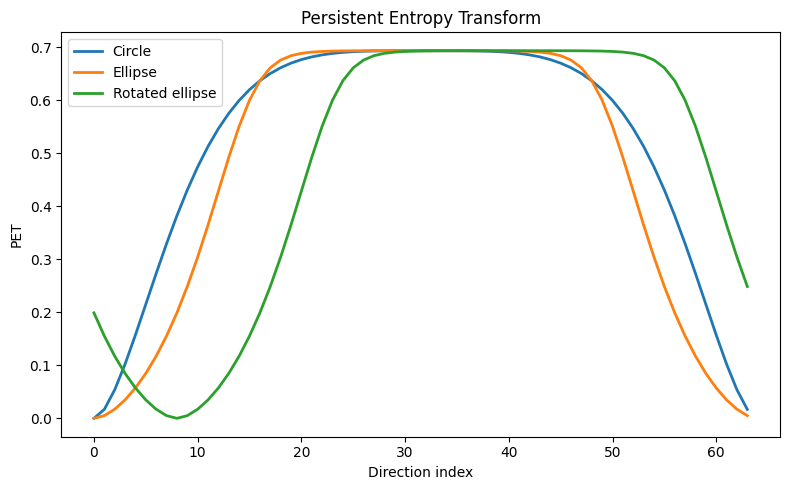

In [9]:

# ---------- SHAPE GENERATORS ----------

def generate_circle(n_points=500, radius=1.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = radius * np.cos(t)
    y = radius * np.sin(t)
    return x, y


def generate_ellipse(n_points=500, a=2.0, b=1.0, rotation=0.0):
    t = np.linspace(0, 2*np.pi, n_points)
    x = a * np.cos(t)
    y = b * np.sin(t)

    R = np.array([
        [np.cos(rotation), -np.sin(rotation)],
        [np.sin(rotation),  np.cos(rotation)]
    ])

    pts = R @ np.vstack([x, y])
    return pts[0], pts[1]


def generate_noisy_shape(x, y, sigma):
    noise_x = np.random.normal(0, sigma, len(x))
    noise_y = np.random.normal(0, sigma, len(y))
    return x + noise_x, y + noise_y

def build_lowerstar_layer(n_points):

    stbase = gd.SimplexTree()

    for i in range(n_points-1):
        stbase.insert([i,i+1], -1e10)

    layer = LowerStarLayer(simplextree=stbase)
    return layer

def compute_pet_from_shape(x, y, layer, num_directions=64):

    x_tf = tf.constant(x, dtype=tf.float32)
    y_tf = tf.constant(y, dtype=tf.float32)

    PET_values, angles = persistent_entropy_transform(
        x_tf,
        y_tf,
        layer,
        num_directions=num_directions
    )

    return PET_values.numpy(), angles


def compute_global_pe(y, layer):
    """
    Global persistent entropy (single filtration).
    """
    y_tf = tf.constant(y, dtype=tf.float32)

    dgms = layer.call(y_tf)
    dgm = dgms[0][0]

    return persistent_entropy(dgm)


def directional_statistics(pet):
    """
    Computes the statistics reported in Table 2.
    """

    mean_pet = np.mean(pet)
    directional_range = np.max(pet) - np.min(pet)
    directional_variance = np.mean((pet - mean_pet) ** 2)

    return mean_pet, directional_range, directional_variance


def equivariance_error(pet_original,
                       pet_rotated,
                       rotation_angle):

    n = len(pet_original)

    shift = int(np.round(rotation_angle / (2*np.pi) * n))

    pet_shifted = np.roll(pet_original, shift)

    return np.max(np.abs(pet_rotated - pet_shifted))

def experiment_directional_sensitivity(layer):

    rotation = np.pi / 4

    shapes = {
        "Circle": generate_circle(),
        "Ellipse": generate_ellipse(a=2, b=1),
        "Rotated ellipse": generate_ellipse(a=2,
                                            b=1,
                                            rotation=rotation)
    }

    results = {}

    plt.figure(figsize=(8,5))

    for name, (x, y) in shapes.items():

        stbase = gd.SimplexTree()

        for i in range(len(y)-1):
            stbase.insert([i, i+1], -1e10)

        layer = LowerStarLayer(simplextree=stbase)

        global_pe = compute_global_pe(y, layer)

        pet, angles = compute_pet_from_shape(x, y, layer)

        mean_pet, drange, dvar = directional_statistics(pet)

        results[name] = {
            "PE": float(global_pe),
            "Mean PET": float(mean_pet),
            "Range": float(drange),
            "Variance": float(dvar),
            "PET": pet
        }
        

        plt.plot(np.arange(len(pet)),
                 pet,
                 lw=2,
                 label=name)

    print("\nTABLE 2")
    print("-"*75)

    df = pd.DataFrame(results).T

    print(df[["PE",
            "Mean PET",
            "Range",
            "Variance"]].round(5))
    
    delta = equivariance_error(
        results["Ellipse"]["PET"],
        results["Rotated ellipse"]["PET"],
        rotation
    )

    table3 = pd.DataFrame({
        "Rotation angle":[rotation],
        "Number of directions":[len(results["Ellipse"]["PET"])],
        "Equivariance error":[delta]
    })

    print("\nTABLE 3")
    print("-"*50)
    print(table3.round(8))

    plt.xlabel("Direction index")
    plt.ylabel("PET")
    plt.title("Persistent Entropy Transform")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/PET_profiles.jpg")
    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

# Run all experiments
experiment_directional_sensitivity(layer)


2) Experimento 2: Noise robustness


=== Experiment 2: Noise robustness ===


c:\Users\cimagroup\Documents\Repositorios\PET\env\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\cimagroup\Documents\Repositorios\PET\env\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


     sigma  mean_delta  mean_distance  std_distance  mean_ratio
0  0.00000     0.00000       0.000000       0.00000         NaN
1  0.05556     0.20037      28.827351       0.30065   144.93913
2  0.11111     0.40613      32.060188       0.21590    79.44562
3  0.16667     0.62120      32.942081       0.17183    53.52990
4  0.22222     0.81919      33.397560       0.19580    41.21540
5  0.27778     1.02696      33.628078       0.18119    32.99620
6  0.33333     1.22818      33.795769       0.15890    27.80629
7  0.38889     1.38898      33.782249       0.16568    24.51380
8  0.44444     1.63612      33.857342       0.16086    20.86899
9  0.50000     1.86265      33.918621       0.19012    18.38393

TABLE 4
--------------------------------------------------------------------------------
   Noise σ   Mean δ  Mean PET distance  Std PET distance  Mean dPET/δ
0  0.00000  0.00000           0.000000           0.00000          NaN
1  0.05556  0.20037          28.827351           0.30065    144.93

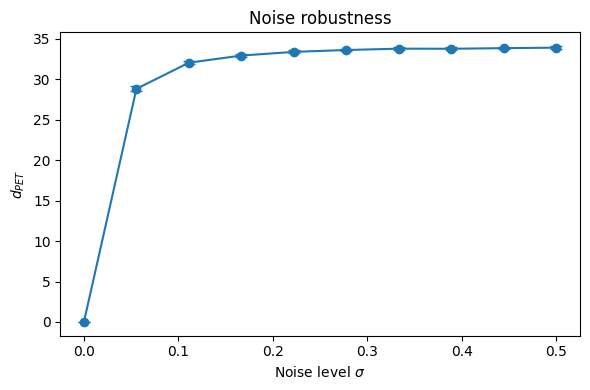

In [10]:
def indexed_vertex_perturbation(x, y, xn, yn):
    """
    Maximum indexed vertex perturbation.
    """

    displacement = np.sqrt((x - xn)**2 + (y - yn)**2)

    return np.max(displacement)

def experiment_noise_stability(layer,
                               repetitions=50):

    print("\n=== Experiment 2: Noise robustness ===")

    x, y = generate_ellipse(a=2, b=1)

    pet_clean, _ = compute_pet_from_shape(x, y, layer)

    sigmas = np.linspace(0, 0.5, 10)

    results = []

    mean_distances = []
    std_distances = []

    for sigma in sigmas:

        delta_values = []
        distance_values = []
        ratio_values = []

        for _ in range(repetitions):

            xn, yn = generate_noisy_shape(x, y, sigma)

            pet_noisy, _ = compute_pet_from_shape(
                xn,
                yn,
                layer
            )

            distance = np.linalg.norm(
                pet_clean - pet_noisy
            )

            delta = indexed_vertex_perturbation(
                x,
                y,
                xn,
                yn
            )

            delta_values.append(delta)
            distance_values.append(distance)

            if delta > 0:
                ratio_values.append(distance / delta)

        results.append({

            "sigma": sigma,

            "mean_delta": np.mean(delta_values),

            "mean_distance": np.mean(distance_values),

            "std_distance": np.std(distance_values),

            "mean_ratio": np.mean(ratio_values)

        })

        mean_distances.append(np.mean(distance_values))
        std_distances.append(np.std(distance_values))

    df = pd.DataFrame(results)

    print(df.round(5))  
    print("\nTABLE 4")
    print("-"*80)

    print(df.rename(columns={

        "sigma":"Noise σ",
        "mean_delta":"Mean δ",
        "mean_distance":"Mean PET distance",
        "std_distance":"Std PET distance",
        "mean_ratio":"Mean dPET/δ"

    }).round(5))

    plt.figure(figsize=(6,4))

    plt.errorbar(
        sigmas,
        mean_distances,
        yerr=std_distances,
        marker="o",
        capsize=4
    )

    plt.xlabel(r"Noise level $\sigma$")
    plt.ylabel(r"$d_{PET}$")
    plt.title("Noise robustness")

    plt.tight_layout()

    plt.savefig("figures/noiseRobustness.jpg")

    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_noise_stability(layer)

Experiment 3: Convergencia por direcciones


=== Experiment 3: Direction sampling ===

TABLE 5
     N       rho     error
0    8  0.390181  0.199320
1   16  0.196034  0.109618
2   32  0.098135  0.051759
3   64  0.049082  0.027051
4  128  0.024543  0.015287


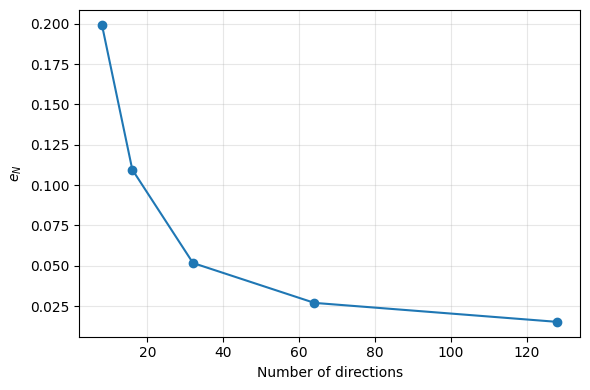

In [11]:
def covering_radius(n_directions):
    """
    Euclidean covering radius on S¹.
    """

    return 2 * np.sin(np.pi / (2 * n_directions))

def approximation_error(reference_pet,
                        coarse_pet):
    """
    Computes

    e_N = sup_v min_w |PET(v)-PET(w)|
    """

    errors = []

    for value in reference_pet:

        nearest = np.min(np.abs(coarse_pet - value))

        errors.append(nearest)

    return np.max(errors)

def experiment_direction_sampling(layer):

    print("\n=== Experiment 3: Direction sampling ===")

    x, y = generate_ellipse(a=2, b=1)

    reference_dirs = 256

    pet_reference, _ = compute_pet_from_shape(
        x,
        y,
        layer,
        reference_dirs
    )

    direction_numbers = [8,16,32,64,128]

    results = []

    approximation_errors = []

    for n in direction_numbers:

        pet, _ = compute_pet_from_shape(
            x,
            y,
            layer,
            n
        )

        error = approximation_error(
            pet_reference,
            pet
        )

        rho = covering_radius(n)

        approximation_errors.append(error)

        results.append({

            "N": n,
            "rho": rho,
            "error": error

        })

    df = pd.DataFrame(results)

    print("\nTABLE 5")
    print(df.round(6))

    plt.figure(figsize=(6,4))

    plt.plot(
        direction_numbers,
        approximation_errors,
        marker="o"
    )

    plt.xlabel("Number of directions")

    plt.ylabel(r"$e_N$")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig("figures/convergence.jpg")

    plt.show()

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_direction_sampling(layer)

Experiment 4: Coste computacional

In [10]:
import time

def experiment_runtime(layer):

    x, y = generate_ellipse()

    for dirs in [8,16,32,64]:
        start = time.time()
        compute_pet_from_shape(x,y,layer,dirs)
        elapsed = time.time() - start

        print(f"Directions={dirs}, time={elapsed:.3f}s")

n_points = 400
layer = build_lowerstar_layer(n_points)

experiment_runtime(layer)

Directions=8, time=0.096s
Directions=16, time=0.177s
Directions=32, time=0.330s
Directions=64, time=0.601s


jupyter nbconvert --to html pet.ipynb